# VEST ordering and model applicability

**Question.** Which asymptotic orderings, and so which reduced plasma models, does the reconstructed VEST
parameter space support, which are marginal, and which cannot yet be assessed? (#1629)

This notebook is a **consumer**. It holds no physics of its own:

| concern | where it lives |
| --- | --- |
| the ordering quantities ($S$, $d_i/a$, $\rho_s/L_{T_e}$, $Kn$, $\nu_*$, ...) | `vaft.formula.ordering` (#1627) |
| which ordering each model assumes (15 contracts) | `vaft.validation.orderings` (#1627) |
| how an ordering becomes a margin and a status | `vaft.validation.applicability` (#1639) |
| computing the quantities for a measured state | `vaft.process.ordering_state` (#1627 §2) |
| assembling the VEST states from the Tier A campaign | `workflow/ordering_atlas/build_states.py` |

The notebook chooses the population, shows the results and interprets them. Every threshold is order unity,
the point where an expansion parameter stops separating scales. The statuses are `SUPPORTED`, `OUTSIDE` and
`UNASSESSED`, with no `MARGINAL`. The continuous margin $m = \pm\log_{10}x$ is the primary result.

In [ ]:
import os
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import vaft
from vaft.process.ordering_state import contract_population, ordering_coverage, ordering_margins, ordering_table
from vaft.validation.applicability import summarize_population
from vaft.validation.orderings import CONTRACTS, ORDERING_QUANTITIES

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3g}".format)
plt.rcParams["figure.dpi"] = 80

ATLAS = Path(os.environ.get("VAFT_ORDERING_ATLAS_DIR", "ordering_atlas")).expanduser()
OFFLINE = not (ATLAS / "states.csv").exists()
print("vaft", vaft.__version__, "| atlas:", ATLAS.name, "| offline fallback:", OFFLINE)

vaft 0.7.1 | atlas: ordering_atlas | offline fallback: False


## 1. Population

**Online.** The population is the #1331 Tier A campaign: magnetics EFIT, graded with criteria v2 (#1521). It is
assembled on vestserver by `workflow/ordering_atlas/build_states.py`. Every assembly choice that script makes is
recorded in its manifest, printed below.

**Offline.** Without that product, the notebook falls back to the in-repository Tier A confinement table, which
has no Thomson data. It still evaluates the orderings that need only geometry, field, density and current.
Everything that needs $T_e$ then stays `UNASSESSED`, and the coverage table says so.

**Why not `vaft.database.summary()`.** #1629 asks for the canonical summaries. Their presets carry neither the
Thomson profile fits nor the EFIT $q$ profile per slice, and their EFIT is the production product rather than
the #1331 campaign's graded reconstructions. So the campaign atlas is the source, and its assembly choices are
recorded in the manifest.

In [ ]:
if OFFLINE:
    from vaft.data.public import load_vest_tier_a_confinement

    raw = load_vest_tier_a_confinement(selection=None)
    states = pd.concat([raw[["shot", "time_s", "efit_quality", "thomson_consistent"]].rename(columns={"time_s": "time_efit_s"}),
                        ordering_table(raw, columns={"n_e": "n_e_line_avg_m3"})], axis=1)
    profiles = pd.DataFrame(columns=["shot", "time_efit_s", "rho_tor_norm"])
    manifest = {"source": "vaft/data/confinement (offline)", "assumptions": ["n_e = line average"]}
else:
    states = pd.read_csv(ATLAS / "states.csv")
    profiles = pd.read_csv(ATLAS / "profiles.csv")
    manifest = json.loads((ATLAS / "manifest.json").read_text())
print(json.dumps({k: manifest[k] for k in manifest if k not in ("atlas", "confinement", "filedb")}, indent=1))
print(f"{len(states)} states from {states.shot.nunique()} shots; {len(profiles)} profile points")
print(states.efit_quality.value_counts().to_dict())

{
 "created": "2026-10-08T05:13:41.465962+00:00",
 "vaft_commit": "3a2aa84436a06c0be02ada4f34c40a38b0d5a532",
 "z_eff_assumed": 2.0,
 "time_tolerance_s": 0.0015,
 "states": 133,
 "profile_rows": 9856,
 "ln_lambda": "NRL electron-ion, coulomb_logarithm_from_n_T at the global n_e, T_e",
 "onset": "vaft.omas.plasma_timing.plasma_timing on the diagnostics ODS (H-alpha first, then I_p)",
 "beta": "beta_normal of the confinement table through the Troyon definition",
 "assumptions": [
  "r = rho_tor_norm * a",
  "B = B0 R0 / (R0 + r)",
  "global n_e, T_e = area-weighted profile means",
  "n_i = n_e",
  "Z_eff constant (assumed)",
  "T_i only where pressure-partition inferred AND Thomson-consistent (criteria v2)"
 ]
}
133 states from 32 shots; 9856 profile points
{'admissible': 115, 'good': 18}


## 2. Coverage and provenance

This section shows which quantities the data can assess at all, grouped by the #1627 data-availability tier.

**What is not assessed.** Perturbation and layer quantities (tier 4) need mode or layer analysis. Flow
quantities (tier 3) need a rotation measurement. Neither is available, so both stay unassessed. That is a fact
about the data, not about VEST.

In [ ]:
merged_profiles = profiles.merge(states, on=["shot", "time_efit_s"], how="left", suffixes=("", "_state"))
coverage = ordering_coverage(states, profiles if len(profiles) else None)
print(coverage.groupby("tier")["assessed"].apply(lambda s: int((s > 0).sum())).rename("quantities with any value"))
display(coverage[coverage.assessed > 0].round(2))
for column in ("q_source", "t_i_source", "onset_source"):
    if column in states:
        print(column, states[column].value_counts().to_dict())
if "ti_over_te_median" in states:
    ratio = states["ti_over_te_median"].dropna()
    print(f"inferred T_i/T_e (median over each state's profile), {len(ratio)} Thomson-consistent states: "
          f"10/50/90 % = {ratio.quantile(0.1):.2f} / {ratio.median():.2f} / {ratio.quantile(0.9):.2f}")

tier
tier1_equilibrium_and_profiles    14
tier2_time_history                 2
tier3_flow                         0
tier4_mode_and_layer               0
Name: quantities with any value, dtype: int64


                                         group                            tier      of  assessed  fraction
quantity                                                                                                  
debye_length_over_L               foundational  tier1_equilibrium_and_profiles  points      9779      0.99
lundquist_number                        global  tier1_equilibrium_and_profiles  states        77      0.58
ion_skin_depth_over_a                   global  tier1_equilibrium_and_profiles  states        77      0.58
inverse_aspect_ratio                    global  tier1_equilibrium_and_profiles  states       133         1
beta                                    global  tier1_equilibrium_and_profiles  states       133         1
beta_over_inverse_aspect_ratio          global  tier1_equilibrium_and_profiles  states       133         1
rho_i_over_LTi                         profile  tier1_equilibrium_and_profiles  points      2310      0.23
rho_s_over_LTe                       

q_source {'efit_slice': 77, 'missing': 56}
t_i_source {'missing': 69, 'inferred_inconsistent': 42, 'inferred': 22}
onset_source {'h_alpha_primary': 133}
inferred T_i/T_e (median over each state's profile), 22 Thomson-consistent states: 10/50/90 % = 1.04 / 1.78 / 4.83


**Provenance.**
- $q$ comes from each state's own EFIT slice.
- $T_e$ and $n_e$ are the Thomson profile fits at the nearest Thomson time.
- $T_i$ is the pressure-partition value, and only on Thomson-consistent states. Even there its median ratio
  to $T_e$ is above one (printed above), which no ohmic VEST plasma carries. So ion orderings are shown
  separately as an upper-bound sensitivity and never enter the main matrix.
- $\beta$ is the confinement table's $\beta_N$ through the Troyon definition.
- $Z_{\rm eff}$ is an explicit assumption, recorded in the manifest.

## 3. Global orderings

One number per state, each on the scale it is defined on:
- the Lundquist number $S$ on $a$;
- $d_i/a$;
- the inverse aspect ratio $\epsilon$;
- $\tau_{\rm evol}/\tau_A$ (from $I_p$) and $\tau_{\rm age}/\tau_R$.

                                count      min      10%      50%     90%      max
lundquist_number                   77 1.86e+04 3.64e+04 1.06e+05 4.7e+05 6.22e+05
ion_skin_depth_over_a              77    0.186     0.22    0.317   0.479    0.621
inverse_aspect_ratio              133    0.641    0.679    0.722   0.749    0.757
beta                              133  0.00681   0.0137   0.0237  0.0441   0.0697
beta_over_inverse_aspect_ratio    133     0.01   0.0184   0.0357  0.0599   0.0936
tau_evolution_over_tau_alfven      77 8.97e+03 1.46e+04 3.67e+04 4.3e+05  1.7e+06
tau_age_over_tau_resistive         77    0.117    0.192    0.568    2.43     7.68

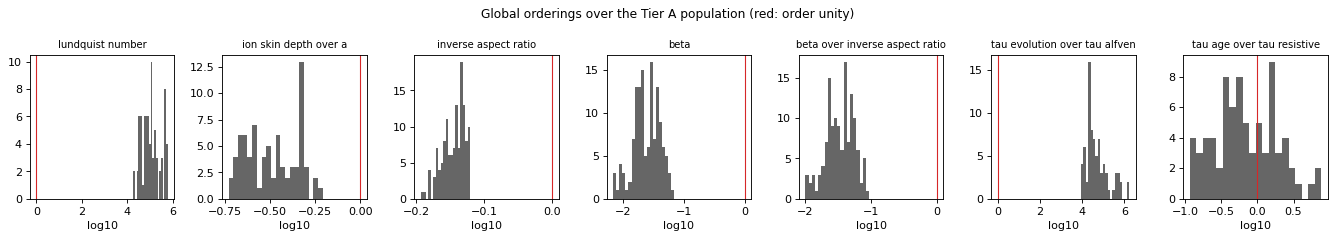

In [ ]:
GLOBAL = [name for name in ("lundquist_number", "ion_skin_depth_over_a", "inverse_aspect_ratio", "beta",
                             "beta_over_inverse_aspect_ratio", "tau_evolution_over_tau_alfven",
                             "tau_age_over_tau_resistive") if name in states]
summary = states[GLOBAL].describe(percentiles=[0.1, 0.5, 0.9]).T[["count", "min", "10%", "50%", "90%", "max"]]
display(summary)

fig, axes = plt.subplots(1, len(GLOBAL), figsize=(2.4 * len(GLOBAL), 3.0))
for ax, name in zip(axes, GLOBAL):
    values = states[name].dropna()
    if len(values):
        ax.hist(np.log10(values), bins=20, color="0.4")
    ax.axvline(0.0, color="tab:red", lw=1)
    ax.set_title(name.replace("_", " "), fontsize=9)
    ax.set_xlabel("log10")
fig.suptitle("Global orderings over the Tier A population (red: order unity)", fontsize=11)
fig.tight_layout()

## 4. Profile orderings

Each quantity is evaluated on every flux surface of every state, on that surface's own gradient length or
connection length. The table bins them in normalised radius. The innermost bin ($\rho < 0.1$) and the outer bin
($\rho > 0.95$) are excluded: gradient lengths there come from one-sided differences or from the fit's boundary.

In [ ]:
PROFILE = ["rho_s_over_LTe", "electron_parallel_knudsen_number", "electron_magnetization",
           "electron_collisionality", "debye_length_over_L"]
ION = ["rho_i_over_LTi", "ion_parallel_knudsen_number", "ion_magnetization", "ion_collisionality"]
inner = merged_profiles[(merged_profiles.rho_tor_norm > 0.1) & (merged_profiles.rho_tor_norm < 0.95)].copy()
if len(inner):
    inner["region"] = pd.cut(inner.rho_tor_norm, [0.1, 0.4, 0.7, 0.95], labels=["core 0.1-0.4", "mid 0.4-0.7", "edge 0.7-0.95"])
    radial = inner.groupby("region", observed=True)[PROFILE].median()
    display(radial.T)
    ion_inferred = inner[inner.t_i_source == "inferred"].groupby("region", observed=True)[ION].median()
    print("ion orderings with the pressure-partition T_i (upper-bound sensitivity, Thomson-consistent states only):")
    display(ion_inferred.T)
else:
    print("no profile data offline")

region                            core 0.1-0.4  mid 0.4-0.7  edge 0.7-0.95
rho_s_over_LTe                          0.0241       0.0401         0.0936
electron_parallel_knudsen_number          3.59         1.61            0.4
electron_magnetization                 2.4e+04     1.14e+04       5.81e+03
electron_collisionality                   3.27         2.46           5.71
debye_length_over_L                   7.43e-05      0.00012       0.000331

ion orderings with the pressure-partition T_i (upper-bound sensitivity, Thomson-consistent states only):


region                       core 0.1-0.4  mid 0.4-0.7  edge 0.7-0.95
rho_i_over_LTi                     0.0874        0.101          0.268
ion_parallel_knudsen_number          23.2         75.9           25.5
ion_magnetization                2.71e+03     7.33e+03       7.07e+03
ion_collisionality                   0.47       0.0581         0.0867

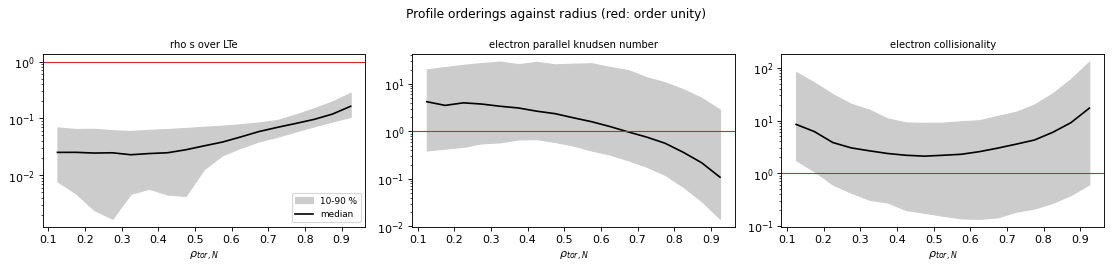

In [ ]:
if len(inner):
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
    for ax, name in zip(axes, ["rho_s_over_LTe", "electron_parallel_knudsen_number", "electron_collisionality"]):
        bins = np.linspace(0.1, 0.95, 18)
        centres = 0.5 * (bins[1:] + bins[:-1])
        groups = pd.cut(inner.rho_tor_norm, bins)
        q = inner.groupby(groups, observed=False)[name].quantile([0.1, 0.5, 0.9]).unstack()
        ax.fill_between(centres, q[0.1], q[0.9], color="0.8", label="10-90 %")
        ax.plot(centres, q[0.5], color="k", label="median")
        ax.axhline(1.0, color="tab:red", lw=1)
        ax.set_yscale("log")
        ax.set_xlabel(r"$\rho_{tor,N}$")
        ax.set_title(name.replace("_", " "), fontsize=9)
    axes[0].legend(fontsize=8)
    fig.suptitle("Profile orderings against radius (red: order unity)", fontsize=11)
    fig.tight_layout()

## 5. Ordering spaces

Four ordering spaces pair the quantities so that two separate assumptions can be read together:
- $S$ against $d_i/a$: resistive against Hall separation;
- $Kn_e$ against $\Omega_{ce}\tau_e$: closure against magnetisation;
- $\rho_s/L_{T_e}$ against $Kn_e$: FLR against collisional fluid;
- $\tau_{\rm evol}/\tau_A$ against $\tau_{\rm age}/\tau_R$: quasi-static against relaxed current.

The reusable versions of these figures are #1627 §3. These are this study's quick views.

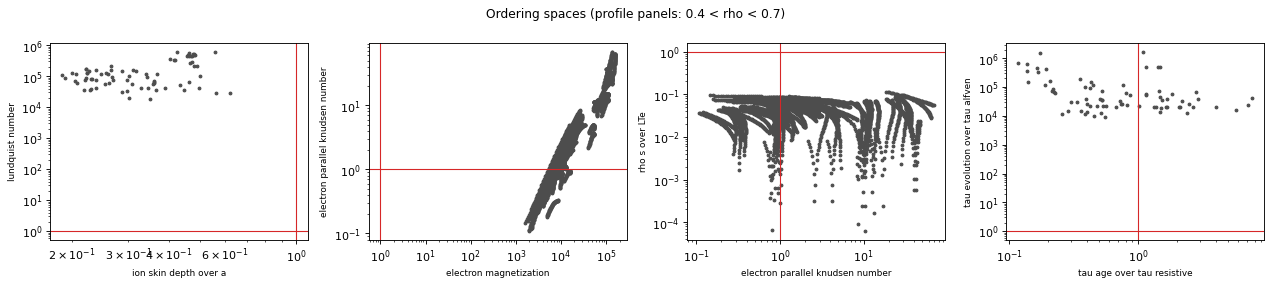

In [ ]:
mid = inner[(inner.rho_tor_norm > 0.4) & (inner.rho_tor_norm < 0.7)] if len(inner) else inner
pairs = [(states, "ion_skin_depth_over_a", "lundquist_number"),
         (mid, "electron_magnetization", "electron_parallel_knudsen_number"),
         (mid, "electron_parallel_knudsen_number", "rho_s_over_LTe"),
         (states, "tau_age_over_tau_resistive", "tau_evolution_over_tau_alfven")]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (frame, x, y) in zip(axes, pairs):
    if len(frame) and x in frame and y in frame:
        ax.scatter(frame[x], frame[y], s=6, color="0.3")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.axvline(1.0, color="tab:red", lw=1); ax.axhline(1.0, color="tab:red", lw=1)
    ax.set_xlabel(x.replace("_", " "), fontsize=8); ax.set_ylabel(y.replace("_", " "), fontsize=8)
fig.suptitle("Ordering spaces (profile panels: 0.4 < rho < 0.7)", fontsize=11)
fig.tight_layout()

## 6. Applicability matrix

**How each contract is evaluated.** A contract whose orderings are all global or time-history is evaluated
once per state. Any other contract is evaluated per flux surface (0.1 < ρ < 0.95), with the state's global
quantities attached.

**How a status is decided.** A contract is `OUTSIDE` as soon as one *evaluated* ordering is violated, whatever is
missing. It is `SUPPORTED` only if every ordering it lists was evaluated and holds. Otherwise it is `UNASSESSED`.

**What the table reports.** It reports both the decided status and, for undecided contracts, which evaluated
orderings hold. Ion orderings are left out of this table (§2).

In [ ]:
points = inner.drop(columns=[c for c in ION if c in inner]) if len(inner) else None
records = []
for name, contract in CONTRACTS.items():
    evaluated = contract_population(contract, states, points)
    summary = summarize_population(evaluated, contract)
    records.append({"contract": name, "on": evaluated.attrs["evaluated_on"], "n": summary["n"],
                    "orderings": len(contract.assumptions), "assessable": len(summary["assessable"]),
                    "SUPPORTED": summary["SUPPORTED"], "OUTSIDE": summary["OUTSIDE"],
                    "UNASSESSED": summary["UNASSESSED"], "evaluated hold": summary["evaluated_hold"],
                    "main limitation": summary["main_limitation"],
                    "unassessed orderings": ", ".join(summary["unassessed"])})
matrix = pd.DataFrame(records).set_index("contract")
for column in ("SUPPORTED", "OUTSIDE", "UNASSESSED", "evaluated hold"):
    matrix[column] = (100 * matrix[column]).round(0)
print("percent of rows; 'on' says whether a contract is evaluated per state or per flux surface")
display(matrix)

percent of rows; 'on' says whether a contract is evaluated per state or per flux surface


                                      on     n  orderings  assessable  SUPPORTED  OUTSIDE  UNASSESSED  evaluated hold                   main limitation  \
contract                                                                                                                                                  
ideal_single_fluid_mhd            points  9323          8           3          0        0         100             100                                     
resistive_mhd                     points  9323          9           2          0        0         100             100                                     
hall_mhd                          points  9323          4           1          0        0         100             100                                     
braginskii_two_fluid              points  9323          7           3          0       57          43              43  electron_parallel_knudsen_number   
flr_small_fluid                   points  9323          3           1 

### Per-ordering margins

The status is secondary; the margin says how much room an ordering has. Below, for each ordering this data
can assess, are the median margin in decades and the fraction on its permitted side. Global orderings are
counted once per state, profile orderings once per flux surface.

In [ ]:
margins = ordering_margins(CONTRACTS, states, points)
margins["median_margin"] = margins["median_margin"].round(2)
margins["permitted"] = (100 * margins["permitted"]).round(0)
display(margins)

                                            per     n  median_margin  permitted
ordering                                                                       
electron_collisionality (small)           point  9323          -0.54         23
tau_age_over_tau_resistive (large)        state    77          -0.25         39
electron_parallel_knudsen_number (small)  point  9323          -0.12         43
inverse_aspect_ratio (small)              state   133           0.14        100
ion_skin_depth_over_a (small)             state    77            0.5        100
rho_s_over_LTe (small)                    point  9323           1.28        100
beta_over_inverse_aspect_ratio (small)    state   133           1.45        100
beta (small)                              state   133           1.63        100
debye_length_over_L (small)               point  9323           3.81        100
electron_magnetization (large)            point  9323           4.02        100
tau_evolution_over_tau_alfven (large)   

### State-level ordering summary

Every global and time-history ordering of each state is listed with its margin, taken from the contracts that
use it. This is a per-state table; the ten states shown are the first in shot order.

In [ ]:
state_level = states[["shot", "time_efit_s", "efit_quality"]].copy()
for name in ("ideal_single_fluid_mhd", "low_beta_reduced_mhd", "quasi_static_equilibrium",
             "resistively_relaxed_current"):
    evaluated = contract_population(CONTRACTS[name], states, None)
    for column in evaluated.columns:
        if column.endswith("_margin") and evaluated[column].notna().any():
            state_level[column] = evaluated[column]
display(state_level.dropna(subset=[c for c in state_level if c.endswith("_margin")], how="all").head(10))

    shot  time_efit_s efit_quality  lundquist_number_margin  ion_skin_depth_over_a_margin  inverse_aspect_ratio_margin  beta_over_inverse_aspect_ratio_margin  \
0  39906        0.319         good                     5.33                          0.32                        0.142                                   1.91   
1  39906         0.32   admissible                     5.33                         0.308                        0.145                                   1.89   
2  39906        0.321   admissible                     5.48                         0.324                        0.155                                   1.88   
3  39906        0.322   admissible                     5.43                          0.33                        0.156                                   1.92   
4  39915        0.315   admissible                     4.57                         0.349                        0.124                                   1.75   
5  39915        0.316   admissible

## 7. Radial applicability

Three local-model families are shown against radius. Each line is the fraction of points where the model's
assessable orderings all hold:
- Braginskii two-fluid closure;
- FLR-small fluid;
- banana-regime neoclassical transport.

The panels show local orderings only, and no conclusion about a whole discharge.

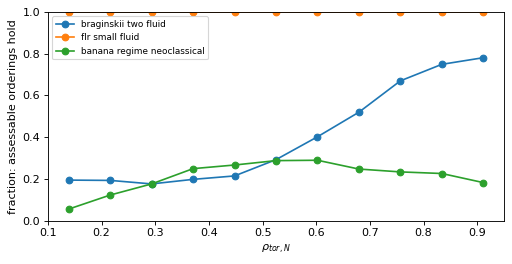

In [ ]:
if len(inner):
    families = ["braginskii_two_fluid", "flr_small_fluid", "banana_regime_neoclassical"]
    bins = np.linspace(0.1, 0.95, 12)
    centres = 0.5 * (bins[1:] + bins[:-1])
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    for name in families:
        evaluated = contract_population(CONTRACTS[name], states, points)
        groups = pd.cut(points.rho_tor_norm, bins)
        frac = [summarize_population(evaluated[groups == g], CONTRACTS[name])["evaluated_hold"]
                for g in groups.cat.categories]
        ax.plot(centres, frac, marker="o", label=name.replace("_", " "))
    ax.set_ylim(0, 1); ax.set_xlabel(r"$\rho_{tor,N}$"); ax.set_ylabel("fraction: assessable orderings hold")
    ax.legend(fontsize=8); fig.tight_layout()

## 8. Temporal applicability

$\tau_{\rm evol}/\tau_A$ is plotted through the shots with the most graded slices. A converged EFIT is not
evidence of a quasi-static plasma. This ratio is.

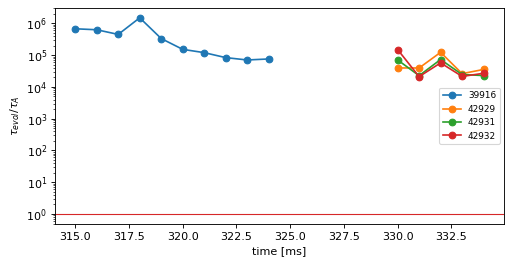

In [ ]:
top = states.dropna(subset=["tau_evolution_over_tau_alfven"]).shot.value_counts().head(4).index
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for shot in top:
    s = states[states.shot == shot].sort_values("time_efit_s")
    ax.plot(1e3 * s.time_efit_s, s.tau_evolution_over_tau_alfven, marker="o", label=str(shot))
ax.set_yscale("log"); ax.axhline(1.0, color="tab:red", lw=1)
ax.set_xlabel("time [ms]"); ax.set_ylabel(r"$\tau_{evol}/\tau_A$"); ax.legend(fontsize=8); fig.tight_layout()

## 9. Representative states for downstream studies

States are chosen by the ordering they would test: low, middle and high $\rho_s/L_{T_e}$ at mid radius (for the
TGLF and CGYRO studies), and low and high $Kn_e$ (for the neoclassical studies). Selection is by *predicted*
applicability, before any solver comparison, so later model comparisons do not set their own thresholds.

In [ ]:
if len(mid):
    per_state = mid.groupby(["shot", "time_efit_s"]).agg(
        rho_s_over_LTe=("rho_s_over_LTe", "median"),
        electron_parallel_knudsen_number=("electron_parallel_knudsen_number", "median"),
        efit_quality=("efit_quality", "first")).dropna()
    picks = []
    for column, label in (("rho_s_over_LTe", "FLR / local GK"), ("electron_parallel_knudsen_number", "fluid closure")):
        ranked = per_state.sort_values(column)
        for tag, index in (("low", 0), ("middle", len(ranked) // 2), ("high", len(ranked) - 1)):
            row = ranked.iloc[index]
            picks.append({"tests": label, "case": tag, "shot": row.name[0], "time_s": row.name[1],
                          "rho_s/L_Te": row.rho_s_over_LTe, "Kn_e": row.electron_parallel_knudsen_number,
                          "efit_quality": row.efit_quality})
    display(pd.DataFrame(picks))

            tests    case   shot  time_s  rho_s/L_Te  Kn_e efit_quality
0  FLR / local GK     low  40282    0.32      0.0141 0.901   admissible
1  FLR / local GK  middle  39906   0.322      0.0357  10.1   admissible
2  FLR / local GK    high  42934   0.332      0.0878 0.783   admissible
3   fluid closure     low  40331   0.323      0.0204 0.201   admissible
4   fluid closure  middle  42929   0.331      0.0459  1.64   admissible
5   fluid closure    high  39916   0.323      0.0553  50.1   admissible

## 10. Downstream validation map

| assumption family | what this notebook established | where it is validated |
| --- | --- | --- |
| large-aspect-ratio geometry | $\epsilon$ distribution (§3) | equilibrium and analytic-formula studies |
| ideal single-fluid MHD | $S$, $d_i/a$, $\rho_s/L$ (§3, §6) | DCON / GPEC notebooks |
| resistive layer physics | global prerequisites only; layer orderings unassessed | RDCON / resistive GPEC |
| local collisional fluid (Braginskii) | $Kn_e$, $\Omega_{ce}\tau_e$ against radius (§4, §7) | neoclassical (NEO) and transport studies |
| FLR-small / local gyrokinetics | $\rho_s/L_{T_e}$ and the representative cases (§9) | TGLF / CGYRO notebooks |
| neoclassical regimes | $\nu_{*e}$ against radius (§4, §7) | `neoclassical_transport_with_neo.ipynb` |
| quasi-static equilibrium | $\tau_{\rm evol}/\tau_A$ (§8) | EFIT and equilibrium-sequence studies |
| relaxed current profile | $\tau_{\rm age}/\tau_R$ (§3) | current-diffusion and $l_i$ studies |

This notebook runs no solver comparison: no Sauter/NEO campaign, no TGLF/CGYRO validation, no ideal/resistive
GPEC comparison, and no convergence study.

## 11. Conclusions

The cell below prints the numbers the conclusions rest on. The text after it is written from those numbers.

In [ ]:
def med(frame, name):
    v = pd.to_numeric(frame.get(name, pd.Series(dtype=float)), errors="coerce").dropna()
    return (float(v.median()), int(len(v))) if len(v) else (float("nan"), 0)

facts = {name: med(states, name) for name in GLOBAL}
if len(inner):
    for name in PROFILE:
        facts[name + " (0.4<rho<0.7)"] = med(mid, name)
    facts["fraction of points with Kn_e > 1 (0.1<rho<0.95)"] = (
        float((inner.electron_parallel_knudsen_number > 1).mean()), int(inner.electron_parallel_knudsen_number.notna().sum()))
    facts["fraction of points with nu*_e > 1 (0.1<rho<0.95)"] = (
        float((inner.electron_collisionality > 1).mean()), int(inner.electron_collisionality.notna().sum()))
t_age = states.tau_age_over_tau_resistive.dropna()
facts["fraction of states with tau_age/tau_R < 1"] = (float((t_age < 1).mean()) if len(t_age) else float("nan"), int(len(t_age)))
if "plasma_age_s" in states:
    age = 1e3 * states.loc[t_age.index, "plasma_age_s"]
    facts["plasma age of those states, min [ms]"] = (float(age.min()) if len(age) else float("nan"), int(len(age)))
    facts["plasma age of those states, max [ms]"] = (float(age.max()) if len(age) else float("nan"), int(len(age)))
for name in ("lundquist_number", "tau_evolution_over_tau_alfven", "ion_skin_depth_over_a"):
    v = states[name].dropna()
    facts[name + " min"] = (float(v.min()) if len(v) else float("nan"), int(len(v)))
    facts[name + " max"] = (float(v.max()) if len(v) else float("nan"), int(len(v)))
for key, (value, n) in facts.items():
    print(f"{key:55s} {value:10.3g}   (n = {n})")

lundquist_number                                          1.06e+05   (n = 77)
ion_skin_depth_over_a                                        0.317   (n = 77)
inverse_aspect_ratio                                         0.722   (n = 133)
beta                                                        0.0237   (n = 133)
beta_over_inverse_aspect_ratio                              0.0357   (n = 133)
tau_evolution_over_tau_alfven                             3.67e+04   (n = 77)
tau_age_over_tau_resistive                                   0.568   (n = 77)
rho_s_over_LTe (0.4<rho<0.7)                                0.0401   (n = 4192)
electron_parallel_knudsen_number (0.4<rho<0.7)                1.61   (n = 4192)
electron_magnetization (0.4<rho<0.7)                      1.14e+04   (n = 4192)
electron_collisionality (0.4<rho<0.7)                         2.46   (n = 4192)
debye_length_over_L (0.4<rho<0.7)                          0.00012   (n = 4192)
fraction of points with Kn_e > 1 (0.1<rho<0.95)    

**What the numbers above say.** These are from the online Tier A run: 133 states from 32 shots, 77 of them with
Thomson profiles. The offline fallback supports none of the $T_e$-dependent statements.

- **Resistive, quasi-static and low-β orderings hold with large margin.**

  | ordering | median margin | minimum value |
  | --- | --- | --- |
  | $S$ | 5.0 decades | $1.9\times10^4$ |
  | $\tau_{\rm evol}/\tau_A$ | 4.6 decades | $9\times10^3$ |
  | $\beta$ | 1.6 decades | — |
  | $\beta/\epsilon$ | 1.5 decades | — |

  At the global scale these do not limit single-fluid or reduced MHD in VEST. Layer-scale resistivity is a
  separate question, and it is unassessed.
- **The aspect ratio gives the least room of any global ordering.** $\epsilon \approx 0.72$ (0.64–0.76) is below
  order unity, so it counts as `SUPPORTED`, but with a margin of only 0.14 decades. The status alone would hide
  this. Expansions in $\epsilon$ (large aspect ratio, reduced MHD) have essentially no small parameter in VEST.
- **Hall separation is next.** $d_i/a$ has a median of 0.32, with a range of 0.19 to 0.62: a margin of 0.5
  decades. Two-fluid corrections have little room.
- **The current profile is generally not resistively relaxed.**
  - $\tau_{\rm age}/\tau_R$ has a median of 0.57 and is below one on 61 % of the 77 states with profiles, at
    plasma ages of 8.6 to 18.7 ms.
  - `resistively_relaxed_current` is the one contract this data decides as a whole. It is `SUPPORTED` on 39 % of
    those 77 states, which is 23 % of all 133 states, since states without profiles are `UNASSESSED`.
- **Local collisional fluid closure fails over most of the profile.**
  - The parallel electron Knudsen number has a median of 3.6 in the core, 1.6 at mid radius and 0.4 at the
    edge, and exceeds one at 57 % of points.
  - The Braginskii two-fluid contract is `OUTSIDE` at 57 % of points, limited by $Kn_e$.
  - Magnetisation $\Omega_{ce}\tau_e \sim 10^4$ holds everywhere.
- **Neither neoclassical asymptote applies over most of the profile.**
  - $\nu_{*e}$ has a median of 2.5 to 5.7 across the regions, so the banana regime is `OUTSIDE` at 77 % of
    points.
  - The Pfirsch–Schlüter contract is `OUTSIDE` at 57 %, also because $Kn_e > 1$.

  Together these point to the plateau regime, or to a regime-spanning solver such as NEO, rather than to either
  asymptotic limit.
- **FLR effects are small but grow outward.** $\rho_s/L_{T_e}$ has a median of 0.024 in the core, 0.040 at mid
  radius and 0.094 at the edge (median margin 1.3 decades).
- **Unassessed:**
  - perturbation, layer and flow orderings: this population has no mode analysis, layer widths or rotation;
  - ion orderings beyond an upper-bound sensitivity: the pressure-partition $T_i$ has a median $T_i/T_e$ of 1.8
    even on the 22 Thomson-consistent states.

  Every contract except `resistively_relaxed_current` lists at least one ordering this data cannot evaluate, so
  none of them is `SUPPORTED` as a whole.